In [26]:
from typing import Literal, TypedDict

from langchain_anthropic import ChatAnthropic
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel

In [27]:
llm = ChatAnthropic(
    model="claude-haiku-4-5",
    temperature=0,
)

In [28]:
class Review(BaseModel):
    approved: bool
    feedback: str


In [29]:
class GraphState(TypedDict):
    topic: str
    draft: str
    feedback: str
    iterations: int

In [30]:
def generate(state: GraphState):
    """Generate or improve the draft."""

    if state["iterations"] == 0:
        prompt = f"Write a short paragraph about {state['topic']}."
    else:
        prompt = f"""
        Improve this paragraph using the feedback.

        Paragraph:
        {state['draft']}

        Feedback:
        {state['feedback']}
        """

    response = llm.invoke(prompt)

    return {
        "draft": response.content,
        "iterations": state["iterations"] + 1,
    }


In [31]:
review_llm = llm.with_structured_output(Review)

def review(state: GraphState):
    """Review the generated draft."""

    result = review_llm.invoke(
        f"""
        Review this paragraph.

        Paragraph:
        {state['draft']}

        Approve only if it is clear, concise, and grammatically correct.
        """
    )

    return {
        "feedback": result.feedback
    }

In [32]:
MAX_ITERATIONS = 3

def route(state: GraphState) -> Literal["end", "generate"]:
    """
    Re-run generation if:
    - reviewer didn't approve
    - max iterations not reached
    """

    result = review_llm.invoke(
        f"""
        Review this paragraph.

        Paragraph:
        {state['draft']}

        Approve only if it is clear, concise, and grammatically correct.
        """
    )
    
    if result.approved:
        return "end"

    if state["iterations"] >= MAX_ITERATIONS:
        return "end"

    return "generate"


In [33]:
builder = StateGraph(GraphState)

builder.add_node("generate", generate)
builder.add_node("review", review)

builder.add_edge(START, "generate")
builder.add_edge("generate", "review")

builder.add_conditional_edges(
    "review",
    route,
    {
        "generate": "generate",
        "end": END,
    },
)

graph = builder.compile()


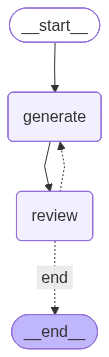

In [34]:
graph

In [35]:
result = graph.invoke(
    {
        "topic": "LangGraph",
        "draft": "",
        "feedback": "",
        "iterations": 0,
    }
)

print(result["draft"])
print(f"Iterations: {result['iterations']}")

# LangGraph

LangGraph is a framework for building stateful, multi-actor applications using language models. Developed by LangChain, it enables developers to create complex workflows by orchestrating multiple AI agents and tools through a graph-based architecture. LangGraph allows you to define nodes (representing actions or decisions) and edges (representing transitions between states), making it ideal for applications that require sequential reasoning, tool use, and human-in-the-loop interactions. With built-in support for persistence, streaming, and debugging, LangGraph simplifies the development of sophisticated AI systems like multi-agent collaborations, autonomous workflows, and conversational applications that need to maintain context and state across multiple steps.
Iterations: 1
